In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score



In [26]:
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns=housing.feature_names)
data["Price"] = housing.target

X = data[['AveRooms']].values
y = data['Price'].values

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [49]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [111]:
w = 0
b = 0

learning_rate = 0.01
epochs = 1000
#store cost value
cost_history = []

n = len(X_train_scaled)
print(X_train_scaled.shape)
for i in range(epochs):
    y_pred = w * X_train_scaled.flatten() + b
    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)
    
    dw = (1/n) * np.sum((y_pred - y_train) * X_train_scaled.flatten())
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        
        print(f"Epoch {i}, Cost = {cost:.4f}")

        y_pred_gd = w * X_test_scaled.flatten() + b

(16512, 1)
Epoch 0, Cost = 2.8149
Epoch 100, Cost = 0.9414
Epoch 200, Cost = 0.6904
Epoch 300, Cost = 0.6568
Epoch 400, Cost = 0.6523
Epoch 500, Cost = 0.6517
Epoch 600, Cost = 0.6516
Epoch 700, Cost = 0.6516
Epoch 800, Cost = 0.6516
Epoch 900, Cost = 0.6516


In [112]:
print("Gradient Descent")
print("----------------")
print("Weight:", w)
print("Bias:", b)
print("MSE:", mean_squared_error(y_test, y_pred_gd))
print("R2 Score:", r2_score(y_test, y_pred_gd))

Gradient Descent
----------------
Weight: 0.18323090648660517
Bias: 2.0718574888450205
MSE: 1.2923212346292208
R2 Score: 0.013803128574378376


In [113]:
X_train_ne = np.c_[np.ones((len(X_train),1)), X_train]
X_test_ne = np.c_[np.ones((len(X_test),1)), X_test]

theta = np.linalg.inv(X_train_ne.T @ X_train_ne) @ X_train_ne.T @ y_train

y_pred_ne = X_test_ne @ theta

In [114]:
print("\nNormal equation")
print("----------------")
print("intercept:", theta[0])
print("Slope:", theta[1])
print("MSE:", mean_squared_error(y_test, y_pred_ne))
print("R2 Score:", r2_score(y_test, y_pred_ne))


Normal equation
----------------
intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


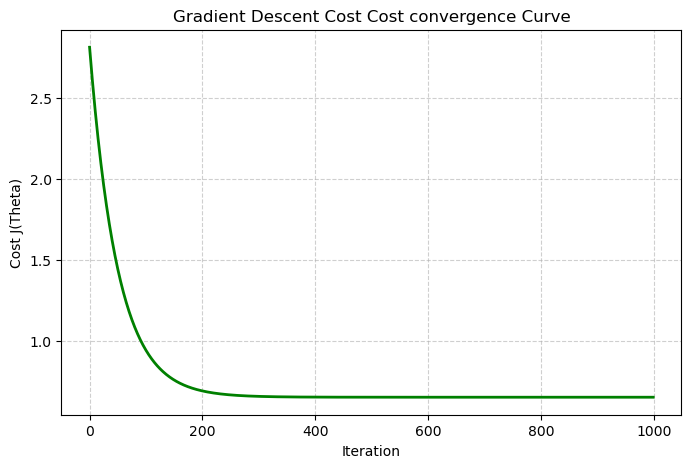

In [135]:
plt.figure(figsize=(8,5))

plt.plot(cost_history, color='green', linewidth=2)

plt.title('Gradient Descent Cost Cost convergence Curve')
plt.xlabel('Iteration')
plt.ylabel('Cost J(Theta)')
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

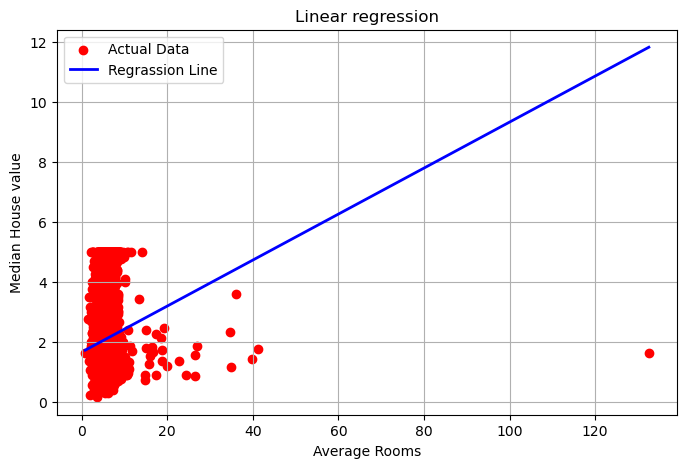

In [186]:
index = np.argsort(X_test.flatten())

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='red', label='Actual Data')
plt.plot(
    X_test.flatten()[index],
    y_pred_ne[index],
    color='blue',
    linewidth=2,
    label='Regrassion Line'
)
plt.title("Linear regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median House value")
plt.legend()
plt.grid(True)

plt.show()
